# Handling Missing Values
**Summer of Science 2026 — CS03: Artificial Intelligence and Machine Learning**  
**Mohit Khyalia | IIT Bombay**

---

## Project Overview

Detecting and handling missing values using isnull, dropna, and fillna.

### Main goals:

- Detect missing values and visualise where they occur.
- Compare dropna() against fillna() on the same dataset.
- Apply mean, median, and mode imputation depending on column type.

---

## Setup and Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white',
                     'axes.spines.top': False, 'axes.spines.right': False})

## Building a Dataset With Known Gaps

In [2]:
np.random.seed(7)
n = 20

df = pd.DataFrame({
    'age':           np.random.randint(21, 60, n).astype(float),
    'income':        np.random.randint(25000, 120000, n).astype(float),
    'credit_score':  np.random.randint(550, 800, n).astype(float),
    'employment_type': np.random.choice(['Salaried', 'Self-Employed', 'Unemployed'], n)
})

df.loc[[2, 7, 14], 'age'] = np.nan
df.loc[[1, 5, 9, 13], 'income'] = np.nan
df.loc[[3, 18], 'credit_score'] = np.nan
df.loc[[0, 10], 'employment_type'] = np.nan

df

,age,income,credit_score,employment_type
0,25.0,70239.0,621.0,NaN
1,46.0,NaN,573.0,Self-Employed
2,NaN,53962.0,560.0,Unemployed
3,40.0,99040.0,NaN,Self-Employed
4,44.0,72305.0,585.0,Self-Employed
5,49.0,NaN,742.0,Self-Employed
6,35.0,56214.0,611.0,Self-Employed
7,NaN,116273.0,685.0,Self-Employed
8,29.0,41215.0,701.0,Unemployed
9,46.0,NaN,642.0,Unemployed


## Detecting Missing Values

In [3]:
print(df.isnull().sum())
print()
print((df.isnull().sum() / len(df) * 100).round(1))

age                3
income             4
credit_score       2
employment_type    2
dtype: int64

age                15.0
income             20.0
credit_score       10.0
employment_type    10.0
dtype: float64


**Observation:**
`.sum()` on top of `isnull()` is what makes it usable — on its own it's just a wall of True/False.

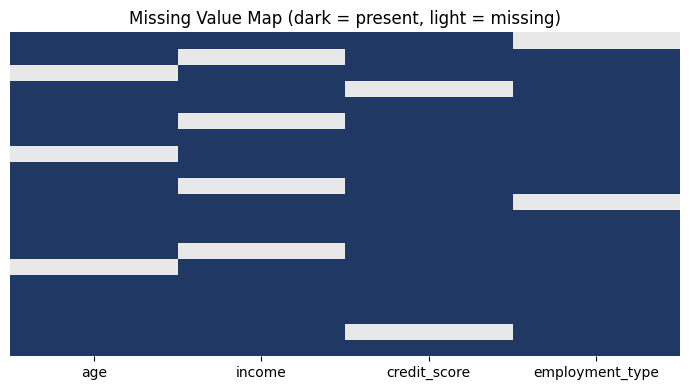

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(df.isnull(), cbar=False, cmap=['#1F3864', '#E8E8E8'], yticklabels=False, ax=ax)
ax.set_title('Missing Value Map (dark = present, light = missing)')
plt.tight_layout()
plt.show()

**Observation:**
Missing values are not clustered in the same rows. If they were, those rows would be better candidates for dropping entirely rather than imputing column by column.

## dropna()

In [5]:
df_dropped = df.dropna()
print(f'Original: {len(df)}  After dropna(): {len(df_dropped)}  Lost: {len(df)-len(df_dropped)} ({(len(df)-len(df_dropped))/len(df)*100:.0f}%)')

Original: 20  After dropna(): 9  Lost: 11 (55%)


**Observation:**
Dropping missing values can significantly reduce the dataset, even when many rows are missing only one value. Imputation often preserves more information while still making the data usable.

In [6]:
df_thresh = df.dropna(thresh=3)
print(f'dropna(thresh=3): {len(df_thresh)} rows kept (vs {len(df_dropped)} with default dropna())')

dropna(thresh=3): 20 rows kept (vs 9 with default dropna())


## fillna() — Mean, Median, Mode

In [7]:
for col in ['age', 'income', 'credit_score']:
    mean_val = df[col].mean()
    median_val = df[col].median()
    print(f'{col:15s}: mean={mean_val:10.1f}  median={median_val:10.1f}  diff={abs(mean_val-median_val):8.1f}')

age            : mean=      36.5  median=      35.0  diff=     1.5
income         : mean=   70051.8  median=   69323.5  diff=   728.3
credit_score   : mean=     677.4  median=     679.0  diff=     1.6


**Observation:**
income has the largest mean/median gap, a skew signal. Used median for income, mean for age and credit_score.

In [8]:
df_filled = df.copy()
df_filled['age'] = df_filled['age'].fillna(df_filled['age'].median())
df_filled['income'] = df_filled['income'].fillna(df_filled['income'].median())
df_filled['credit_score'] = df_filled['credit_score'].fillna(df_filled['credit_score'].mean())

mode_value = df_filled['employment_type'].mode()[0]
df_filled['employment_type'] = df_filled['employment_type'].fillna(mode_value)

df_filled.isnull().sum()

age                0
income             0
credit_score       0
employment_type    0
dtype: int64

**Observation:**
`.mode()` returns a Series, not a scalar — needs `[0]` to index into.

## Comparing dropna() vs fillna()

In [9]:
comparison = pd.DataFrame({
    'Approach': ['Original (with NaN)', 'dropna()', 'fillna()'],
    'Rows Kept': [len(df), len(df_dropped), len(df_filled)],
    'Mean Income': [df['income'].mean(), df_dropped['income'].mean(), df_filled['income'].mean()]
})
comparison['Mean Income'] = comparison['Mean Income'].round(0)
comparison

,Approach,Rows Kept,Mean Income
0,Original (with NaN),20,70052.0
1,dropna(),9,66400.0
2,fillna(),20,69906.0


**Observation:**
Mean income differs between the dropped and filled versions. Dropping rows is not neutral — it changes the statistics of whatever data remains.

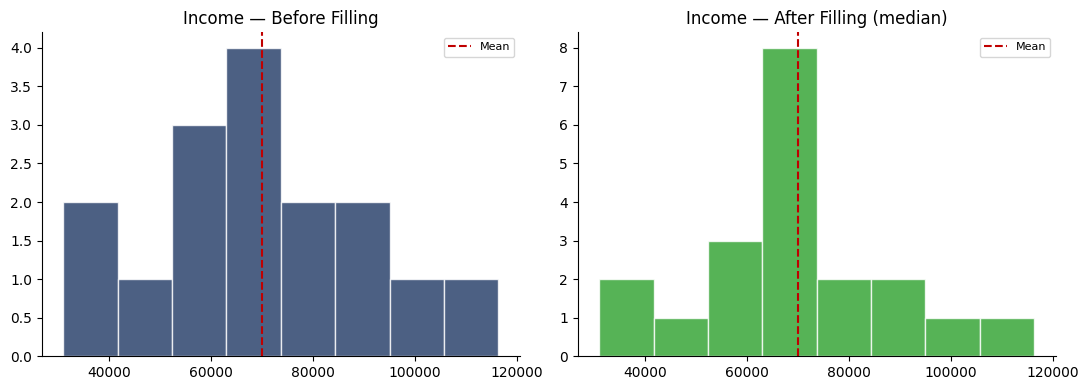

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(df['income'].dropna(), bins=8, color='#1F3864', alpha=0.8, edgecolor='white')
axes[0].axvline(df['income'].mean(), color='#C00000', linestyle='--', label='Mean')
axes[0].set_title('Income — Before Filling')
axes[0].legend(fontsize=8)

axes[1].hist(df_filled['income'], bins=8, color='#2CA02C', alpha=0.8, edgecolor='white')
axes[1].axvline(df_filled['income'].mean(), color='#C00000', linestyle='--', label='Mean')
axes[1].set_title('Income — After Filling (median)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

**Observation:**
The bar at the median is visibly taller after filling, since every missing value became the same number. A high missing percentage could create an artificial spike.

## Comparing Fill Strategies

In [11]:
income_col = df['income']
strategies = {
    'Mean':   income_col.fillna(income_col.mean()),
    'Median': income_col.fillna(income_col.median()),
    'Zero':   income_col.fillna(0)
}
for name, filled in strategies.items():
    print(f'{name:8s}  mean={filled.mean():10.0f}  std={filled.std():10.0f}')

Mean      mean=     70052  std=     19858
Median    mean=     69906  std=     19860
Zero      mean=     56041  std=     34940


**Observation:**
Filling with 0 distorts both mean and standard deviation. A constant fill value only makes sense when it is actually meaningful for that feature.